In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import networkx as nx

In [25]:
# ==============================
# PARÂMETROS GERAIS
# ==============================

L = 5
n_lagartos = L**2
estrategias = ['O', 'Y', 'B']

a = 2
b = 1/a

matriz_payoff = np.array([[1, b, a],
                          [a, 1, b],
                          [b, a, 1]])

index_map = {'O': 0, 'Y': 1, 'B': 2}

n_geracoes = 2
n_pop = 1
A = 0.05
wO = 0.00
wB = 0.75
wY = 0.75

output_dir = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/Montecarlo_sobreposicao_geracao/teste_redes/"
os.makedirs(output_dir, exist_ok=True)

In [26]:
# ==============================
# CLASSE LAGARTO
# ==============================

class Lagarto:
    def __init__(self, i, j, raio, estrategia, fitness,
                 coord_vizinhos, coord_vizinhanca_extendida,
                 estrategia_vizinhanca_extendida, n_vizinhos):
        self.i = i
        self.j = j
        self.raio = raio
        self.estrategia = estrategia
        self.fitness = 0
        self.coord_vizinhos = []
        self.coord_vizinhanca_extendida = []
        self.estrategia_vizinhanca_extendida = []
        self.n_vizinhos = 0

    def calcular_coord_vizinhos(self, L):
        r = self.raio

        lista_vizinhos = []
        for dx in range(-r, r+1):
            for dy in range(-r, r+1):
                if abs(dx) + abs(dy) <= r and not (dx == 0 and dy == 0): #Von neuman
                #if not (dx == 0 and dy == 0):
                    ni = (self.i + dx) % L
                    nj = (self.j + dy) % L
                    lista_vizinhos.append((ni, nj))
        self.coord_vizinhos = lista_vizinhos

    def calcular_n_vizinhos(self):
      self.n_vizinhos = len(self.coord_vizinhos) + len(self.coord_vizinhanca_extendida)

    def mortalidade(self, A, w):
        return 1 / (1 + A * np.exp(w * self.fitness))

    def calcular_fitness(self, mapa):
        fitness_total = 0
        todos_vizinhos = set(self.coord_vizinhos + self.coord_vizinhanca_extendida)
        for ni, nj in todos_vizinhos:
            vizinho = mapa.get((ni, nj))
            if vizinho is not None:
                fitness_total += matriz_payoff[index_map[self.estrategia], index_map[vizinho.estrategia]]
        self.fitness = fitness_total

    def calcular_fitness_rede(self, G):
        fitness_total = 0
        for vizinho in G.successors(self):
            fitness_total += matriz_payoff[index_map[self.estrategia], index_map[vizinho.estrategia]]
        for vizinho in G.predecessors(self):
            fitness_total += matriz_payoff[index_map[self.estrategia], index_map[vizinho.estrategia]]
        
        self.fitness = fitness_total
    
    def atualizar_links_lagarto(self, G, L, lista_lagartos):
        G.remove_edges_from(list(G.out_edges(self)))
        self.calcular_coord_vizinhos(L)
        for (ni, nj) in self.coord_vizinhos:
            vizinho = next(l for l in lista_lagartos if l.i == ni and l.j == nj)
            G.add_edge(self, vizinho)

    def ajustar_vizinhos_reciprocos(self, mapa): 
        self.coord_vizinhanca_extendida = []
        self.estrategia_vizinhanca_extendida = []
        
        for (ni, nj) in self.coord_vizinhos: 
                vizinho = mapa[(ni, nj)]
                if (self.i, self.j) not in vizinho.coord_vizinhos:
                    vizinho.estrategia_vizinhanca_extendida.append(str(self.estrategia))
                    vizinho.coord_vizinhanca_extendida.append((self.i, self.j))
                    print(f"Ajustando vizinho recíproco: Lagarto ({self.i}, {self.j}) adiciona ({ni}, {nj}) como vizinho estendido")

# ==============================
# FUNÇÕES AUXILIARES
# ==============================

def criar_lagartos():
    lista = []
    for i in range(L):
        for j in range(L):
            estrategia = np.random.choice(estrategias)
            if estrategia == 'O':
                raio = 1
            elif estrategia == 'Y':
                raio = 1
            else:
                raio = 1
            lista.append(Lagarto(i, j, raio, estrategia, 0, [], [], [], 0))
    return lista

def calcular_freq(matriz):
    return np.array([np.sum(matriz == s) / (L**2) for s in estrategias])

def media_vizinhos(lista_lagartos):
    return np.mean([l.n_vizinhos for l in lista_lagartos])

def media_vizinhos_por_estrategia(lista_lagartos):
    medias = []
    for e in estrategias:
        raios = [l.n_vizinhos for l in lista_lagartos if l.estrategia == e]
        medias.append(np.mean(raios) if len(raios) > 0 else np.nan)
    return medias

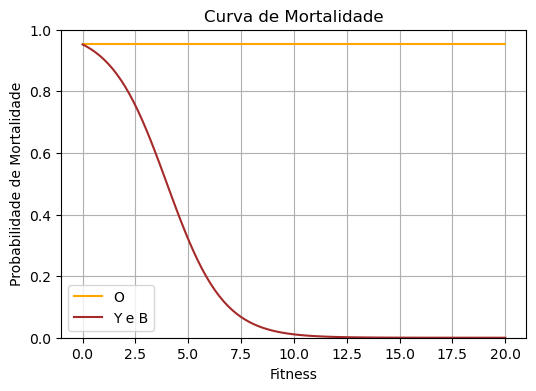

In [27]:
def mortalidade(fitness, A, w):
    return 1 / (1 + A * np.exp(w * fitness))

plt.figure(figsize=(6, 4))
x = np.linspace(0, 20, 100)
y0 = mortalidade(x, A = 0.05, w = wO)
y1 = mortalidade(x, A = 0.05, w = wY)
y2 = mortalidade(x, A = 0.05, w = wB)
plt.plot(x, y0, color = 'orange', label = 'O')
plt.plot(x, y1, color = 'brown', label = 'Y e B')
#plt.plot(x, y2)
#plt.plot(x, y3)
#plt.plot(x, y4)
plt.xlabel('Fitness')
plt.ylabel('Probabilidade de Mortalidade')
plt.title('Curva de Mortalidade')
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()

In [31]:
# ==============================
# SIMULAÇÃO
# ==============================

def simulacao(A, wO, wY, wB, seed=None):

    resultados = []
    
    for pop in range(n_pop):

        if seed is not None:
            np.random.seed(seed + pop)

        G = nx.DiGraph() # cria uma rede direcionada
        lista_lagartos = criar_lagartos()
        for lagarto in lista_lagartos: # adiciona os lagartos como nós na rede
            G.add_node(lagarto)
        
        for lagarto in lista_lagartos:
            lagarto.calcular_coord_vizinhos(L)
            for (ni, nj) in lagarto.coord_vizinhos:
                vizinho = next(l for l in lista_lagartos if l.i == ni and l.j == nj)
                G.add_edge(lagarto, vizinho)  # lagarto interage com vizinho

        redes_geracoes = []

        redes_geracoes.append(G.copy())

        mapa = {(l.i, l.j): l for l in lista_lagartos}

        matriz_posicao = np.empty((L, L), dtype=object)
        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia

        freq = calcular_freq(matriz_posicao)
        vizinhos_mean = media_vizinhos(lista_lagartos)
        r_por_estrat = media_vizinhos_por_estrategia(lista_lagartos)
        resultados.append({
            "pop": pop,
            "t": -1,
            "freq_O": freq[0],
            "freq_Y": freq[1],
            "freq_B": freq[2],
            "vizinhos_mean": vizinhos_mean,
            "vizinhos_mean_O": r_por_estrat[0],
            "vizinhos_mean_Y": r_por_estrat[1],
            "vizinhos_mean_B": r_por_estrat[2],
        })

        for t in range(n_geracoes):
            print(f"População {pop+1} - Geração {t+1}/{n_geracoes}")

            for _ in range(L * L): # faz o sorteio de L^2 células para completar uma geração
                i = np.random.randint(0, L)
                j = np.random.randint(0, L)
                lagarto = mapa[(i, j)] # lagarto sorteado
                
                lagarto.calcular_coord_vizinhos(L) # define os vizinhos do lagarto sorteado   
                #lagarto.ajustar_vizinhos_reciprocos(mapa) # ajusta os vizinhos recíprocos do lagarto sorteado
                lagarto.calcular_n_vizinhos()
                lagarto.calcular_fitness_rede(G) # calcula o fitness apenas do lagarto sorteado
                
                if lagarto.estrategia == 'O':
                    d = lagarto.mortalidade(A, wO)
                elif lagarto.estrategia == 'Y':
                    d = lagarto.mortalidade(A, wY)
                else:
                    d = lagarto.mortalidade(A, wB)
                
                if np.random.rand() > d: # se o número sorteado for maior que a probabilidade de mortalidade, o lagarto sobrevive e mantém sua estratégia
                    pass
                else: # se o lagarto morrer, ele adota a melhor estratégia entre seus vizinhos
                    maior_fitness = 0

                    for (ni, nj) in lagarto.coord_vizinhos: # olha pros vizinhos do lagarto sorteado
                        vizinho = mapa[(ni, nj)]
                        vizinho.calcular_coord_vizinhos(L) # define os vizinhos do vizinho
                        #vizinho.ajustar_vizinhos_reciprocos(mapa) # ajusta os vizinhos recíprocos do vizinho
                        vizinho.calcular_n_vizinhos()
                        vizinho.calcular_fitness_rede(G) # pega o fitness do vizinho

                        if vizinho.fitness <= 0:
                            print("Erro, fitness é:", vizinho.fitness)

                        if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior_fitness encontrado até agora, atualiza o maior_fitness e a melhor_estratégia
                            maior_fitness = vizinho.fitness
                            melhor_estrategia = vizinho.estrategia
                            melhor_raio = vizinho.raio
                        elif vizinho.fitness == maior_fitness: # se for igual, sorteia entre manter a melhor estratégia atual ou adotar a do vizinho
                            a = np.random.rand()
                            if a < 0.5:
                                melhor_estrategia = vizinho.estrategia
                                melhor_raio = vizinho.raio
                            else:
                                pass
                        else: # se for menor, mantém a melhor estratégia atual
                            pass

                    lagarto.estrategia = melhor_estrategia # adota a melhor estratégia encontrada entre os vizinhos           
                    lagarto.raio = melhor_raio # adota o melhor raio encontrado entre os vizinhos

                    lagarto.atualizar_links_lagarto(G, L, lista_lagartos)

                redes_geracoes.append(G.copy())

            for l in lista_lagartos:
                matriz_posicao[l.i, l.j] = l.estrategia

            print(matriz_posicao)

            t += 1

            freq = calcular_freq(matriz_posicao)
            vizinhos_mean = media_vizinhos(lista_lagartos)
            r_por_estrat = media_vizinhos_por_estrategia(lista_lagartos)

            resultados.append({
                "pop": pop,
                "t": t,
                "freq_O": freq[0],
                "freq_Y": freq[1],
                "freq_B": freq[2],
                "vizinhos_mean": vizinhos_mean,
                "vizinhos_mean_O": r_por_estrat[0],
                "vizinhos_mean_Y": r_por_estrat[1],
                "vizinhos_mean_B": r_por_estrat[2],
            })

    return pd.DataFrame(resultados), redes_geracoes


# ==============================
# RODAR
# ==============================

df, redes_geracoes = simulacao(A = A, wO = wO, wY = wY, wB = wB, seed = 2)
#df.to_csv(os.path.join(output_dir, "resultados.csv"), index=False)

print("Simulação concluída.")

População 1 - Geração 1/2
[['O' 'Y' 'Y' 'B' 'B']
 ['O' 'B' 'Y' 'B' 'B']
 ['O' 'O' 'O' 'Y' 'B']
 ['Y' 'O' 'B' 'B' 'Y']
 ['B' 'O' 'Y' 'Y' 'O']]
População 1 - Geração 2/2
[['O' 'Y' 'Y' 'B' 'B']
 ['B' 'B' 'Y' 'B' 'B']
 ['O' 'Y' 'O' 'Y' 'B']
 ['Y' 'Y' 'B' 'B' 'Y']
 ['B' 'O' 'Y' 'Y' 'Y']]
Simulação concluída.


In [41]:
plotar_rede(redes_geracoes[50])
plt.show()

IndexError: list index out of range

In [33]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.animation as animation

def plotar_rede(G, titulo="Rede de Interações"):
    pos = {lagarto: (lagarto.j, lagarto.i) for lagarto in G.nodes}  # note a inversão para alinhar com matriz
    cores = []
    for lagarto in G.nodes:
        if lagarto.estrategia == 'O':
            cores.append('#FD9800')
        elif lagarto.estrategia == 'Y':
            cores.append('#FFF237')
        else:
            cores.append('#0047B3')
    nx.draw(G, pos, with_labels=False, node_size=200, node_color=cores, edge_color='gray', arrows=True)
    plt.title(titulo)
    plt.gca().set_aspect('equal')
    plt.xlim(-1, L)
    plt.ylim(-1, L)
    plt.gca().invert_yaxis()


In [ ]:
    
# Supondo que você armazene os grafos de cada geração em uma lista chamada redes_geracoes
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    plotar_rede(redes_geracoes[frame], titulo=f"Geração {frame}")

ani = animation.FuncAnimation(fig, update, frames=len(redes_geracoes), interval=1000, repeat=False)
plt.show()